# Setup python environment

In [1]:
%pip install pandas numpy matplotlib tensorflow scikit-learn ai_edge_litert

Note: you may need to restart the kernel to use updated packages.


In [48]:
import numpy as np
import tensorflow as tf
import random
import os

# Set the seed for reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)


# Constants

In [125]:
FEATURE_COLS = ["gas_resistance"]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "label"
SEQ_LEN = 10

CLASSES = [
    "air",
    "basil",
    "cinnamon",
    "oregano",
    "rosemary"
]

SAMPLE_TYPES = ["closed_container", "open_room"]

NUM_CLASSES = len(CLASSES)

SAVE_PATH = "../models/cnn/"
MODEL_NAME = "outliers_dropped"

# Load Data

In [126]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    
    # Ensure correct order
    df = df.sort_values(["id", "position"])
    
    for col in feature_cols:
        df[col + "_diff"] = df.groupby("id")[col].diff()
    
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str, sample_types: list) -> pd.DataFrame:
    dfs = []
    i = 0
    for folder in os.listdir(base_dir):
        if folder not in CLASSES:
            continue

        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue

            has_desired_type = False
            for st in sample_types:
                if st in os.path.basename(file):
                    has_desired_type = True
                    break
            if not has_desired_type: continue


            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)
            df['id'] = df.apply(lambda x: f"{i}_{x['sensor_index']}_{x['fingerprint_index']}", axis=1)
            i += 1
            dfs.append(df)

    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)



data = load_dataset("../data/dataset/base", SAMPLE_TYPES)
data = add_fotd_features(data, FEATURE_COLS)
print(len(data["id"].unique()), " fingerprints loaded.")
data.head(50)

12216  fingerprints loaded.


,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,gas_resistance_diff
0,1,0,1,100,150,24.39,1022.75,46.61,414156,air,0_1_0,0.0
8,1,0,2,100,150,24.44,1022.75,46.50,430886,air,0_1_0,16730.0
22,1,0,4,200,150,24.53,1022.75,46.22,67068,air,0_1_0,-363818.0
30,1,0,5,200,150,24.57,1022.76,45.90,68468,air,0_1_0,1400.0
39,1,0,6,200,150,24.61,1022.76,45.95,68688,air,0_1_0,220.0
46,1,1,0,320,150,24.72,1022.76,45.30,10695,air,0_1_1,0.0
54,1,1,1,100,150,24.79,1022.76,45.18,247283,air,0_1_1,236588.0
62,1,1,2,100,150,24.82,1022.75,45.07,262295,air,0_1_1,15012.0
70,1,1,3,100,150,24.84,1022.75,45.04,277883,air,0_1_1,15588.0
78,1,1,4,200,150,24.86,1022.76,44.86,45230,air,0_1_1,-232653.0


#### Drop Outliers

In [140]:
data_cleaned = data.copy() 
# for feat in FEATURE_COLS_EXTENDED:
#     means  = data.groupby('plate_temperature')[feat].mean()
#     stds   = data.groupby('plate_temperature')[feat].std()
#     for temp in means.index:
#         data_cleaned = data_cleaned[abs(data_cleaned[feat] - means[temp]) < 5 * stds[temp]]
data_cleaned = data_cleaned[data_cleaned["fingerprint_index"] > 15]


In [141]:
len(data), len(data_cleaned)

(116204, 103039)

Drop incomplete fingerprints.

In [142]:
complete_ids = []
grouped = data_cleaned.groupby("id")
for group in grouped:
    seq_len = len(group[1])
    if seq_len == SEQ_LEN:
        complete_ids.append(group[0])

data_cleaned = data_cleaned[data_cleaned["id"].isin(complete_ids)]
print("Number of complete fingerprints per class: ")
for cls in CLASSES:
    print(
        f"{cls+' '*(max(map(len, CLASSES)) - len(cls))}\t{len(data_cleaned[data_cleaned[TARGET_COL] == cls]["id"].unique())}"
    )

Number of complete fingerprints per class: 
air     	1911
basil   	1248
cinnamon	1243
oregano 	1257
rosemary	1277


## Split Data

This has to happen at this stage to prevent data leakage.

For the final version that gets exported, use all the available data, but we need train-test split for in-place evaluation.

In [143]:
TEST_RATIO = 0.3
train_data_ids = np.random.choice(complete_ids, size=int(len(complete_ids)*(1 - TEST_RATIO)), replace=False)
train_data = data[data["id"].isin(train_data_ids)]
test_data = data[data["id"].isin([i for i in complete_ids if i not in train_data_ids])]

print("Number of training fingerprints: ",len(train_data["id"].unique()))
print("Number of testing fingerprints: ", len(test_data["id"].unique()))

Number of training fingerprints:  4855
Number of testing fingerprints:  2081


# Neural Network

## Data preprocessing

#### Scaling

In [144]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Encode labels ---
label_encoder = LabelEncoder()
train_data['label_enc'] = label_encoder.fit_transform(train_data[TARGET_COL])
test_data['label_enc'] = label_encoder.transform(test_data[TARGET_COL])

# --- Copy datasets ---
train_data_scaled = train_data.copy()
test_data_scaled = test_data.copy()

# --- Helper for training scaling ---
def scale_group(series: pd.Series) -> pd.Series:
    scaler = StandardScaler()
    return pd.Series(
        scaler.fit_transform(series.values.reshape(-1, 1)).flatten(),
        index=series.index
    )

# --- Scale TRAIN data (fit scalers per plate_temperature) ---
scaling_stats = {}

for feat in FEATURE_COLS_EXTENDED:
    # Scale training data per temperature
    train_data_scaled[feat] = train_data.groupby('plate_temperature')[feat].transform(scale_group)

    # Store stats for test scaling
    means = train_data.groupby('plate_temperature')[feat].mean()
    stds  = train_data.groupby('plate_temperature')[feat].std().replace(0, 1.0)

    scaling_stats[feat] = {
        "mean": means,
        "std": stds,
    }

# --- Apply SAME scaling to TEST data ---
for feat in FEATURE_COLS_EXTENDED:
    means = scaling_stats[feat]["mean"]
    stds  = scaling_stats[feat]["std"]

    # Map each row's plate_temperature → mean/std from TRAIN
    test_means = test_data_scaled["plate_temperature"].map(means)
    test_stds  = test_data_scaled["plate_temperature"].map(stds)

    # Handle unseen temperatures (fallback to global stats)
    global_mean = train_data[feat].mean()
    global_std  = train_data[feat].std() or 1.0

    test_means = test_means.fillna(global_mean)
    test_stds  = test_stds.fillna(global_std).replace(0, 1.0)

    # Apply scaling
    test_data_scaled[feat] = (test_data_scaled[feat] - test_means) / test_stds

In [145]:
label_encoder.classes_

array(['air', 'basil', 'cinnamon', 'oregano', 'rosemary'], dtype=object)

In [146]:
train_data_scaled

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,id,gas_resistance_diff,label_enc
7714,1,100,0,320,150,31.00,1023.13,32.95,1.833340,air,0_1_100,0.414243,0
7722,1,100,1,100,150,31.01,1023.13,32.76,1.827362,air,0_1_100,2.458738,0
7729,1,100,2,100,150,30.99,1023.13,32.77,1.406462,air,0_1_100,-0.743005,0
7737,1,100,3,100,150,30.96,1023.13,32.70,1.185160,air,0_1_100,-0.580955,0
7744,1,100,4,200,150,30.93,1023.14,32.80,1.960106,air,0_1_100,-2.778627,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103022,8,96,5,200,150,30.23,1001.89,36.97,-0.705532,rosemary,9_8_96,0.577616,4
103030,8,96,6,200,150,30.23,1001.90,36.92,-0.785710,rosemary,9_8_96,0.582116,4
103039,8,96,7,320,150,30.24,1001.90,37.05,-0.959588,rosemary,9_8_96,-0.652419,4
103048,8,96,8,320,150,30.27,1001.91,36.97,-0.532580,rosemary,9_8_96,0.525693,4


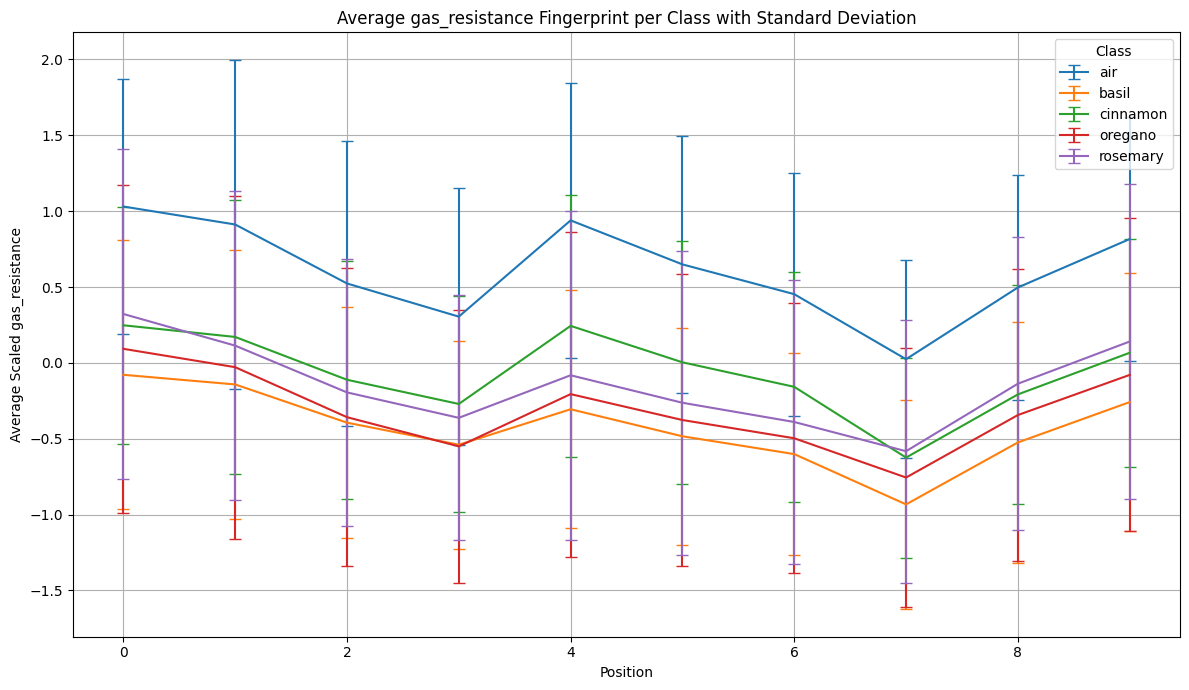

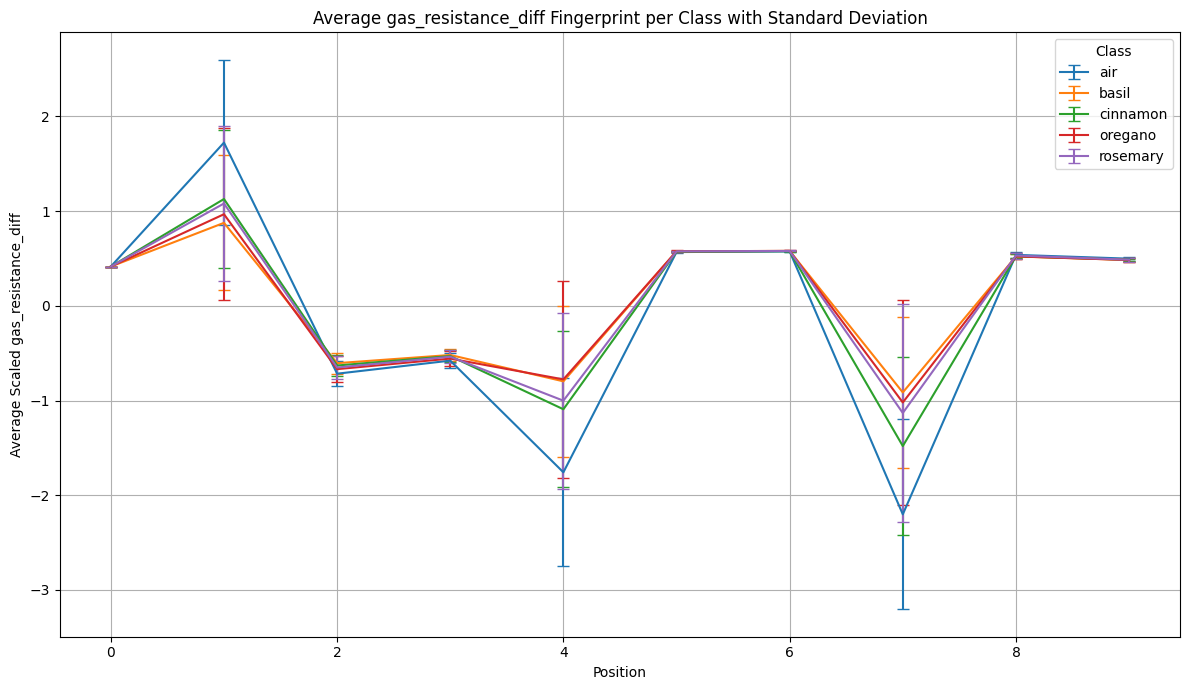

In [147]:
import matplotlib.pyplot as plt

for feat in FEATURE_COLS_EXTENDED:
    # Calculate mean and standard deviation of scaled_gas_resistance grouped by label and position
    fingerprint_stats = train_data_scaled.groupby(['label', 'position'])[feat].agg(['mean', 'std']).reset_index()
    fingerprint_stats.rename(columns={'mean': f'avg_scaled_{feat}', 'std': f'std_scaled_{feat}'}, inplace=True)

    # Get unique labels to iterate through
    classes = fingerprint_stats['label'].unique()

    plt.figure(figsize=(12, 7))

    # Plot each class's fingerprint
    for cls in classes:
        class_data = fingerprint_stats[fingerprint_stats['label'] == cls]
        plt.errorbar(x=class_data['position'],
                    y=class_data[f'avg_scaled_{feat}'],
                    yerr=class_data[f'std_scaled_{feat}'],
                    label=cls,
                    capsize=4) # Add caps to the error bars

    plt.xlabel('Position')
    plt.ylabel(f'Average Scaled {feat}')
    plt.title(f'Average {feat} Fingerprint per Class with Standard Deviation')
    plt.legend(title='Class')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Export Train Data

In [148]:
model_dir = os.path.join(SAVE_PATH, MODEL_NAME)
if not os.path.isdir(model_dir): os.mkdir(model_dir)
train_data.to_csv(os.path.join(model_dir, "train_data.csv"))

### Create Sequences

In [149]:
import numpy as np

def create_sequences_grouped(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    seq_len: int
):
    X, y = [], []
    grouped = df.groupby("id")
    num_skipped = 0
    for _id, group in grouped:
        group = group.sort_values("position")
        data = group[feature_cols].values

        if len(data) == seq_len:
            X.append(data)
            y.append(int(group[target_col].iloc[0]))
        else:
            num_skipped += 1
    print("Number of sequences skipped: ", num_skipped)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train_seq, y_train_seq = create_sequences_grouped(train_data_scaled, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)
X_test_seq, y_test_seq = create_sequences_grouped(test_data_scaled, FEATURE_COLS_EXTENDED, 'label_enc', SEQ_LEN)

Number of sequences skipped:  0
Number of sequences skipped:  0


## Build model

In [150]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D

model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED))),

    Conv1D(16, kernel_size=3, activation='relu'),
    Conv1D(16, kernel_size=3, activation='relu'),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 8, 16)          │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 6, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,605 (6.27 KB)

 Trainable params: 1,605 (6.27 KB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [151]:
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_seq,
    y_train_seq,
    test_size=0.1,
    stratify=y_train_seq,
    random_state=42
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2451 - loss: 1.5739 - val_accuracy: 0.2757 - val_loss: 1.5256
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3207 - loss: 1.5117 - val_accuracy: 0.3251 - val_loss: 1.4822
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3468 - loss: 1.4815 - val_accuracy: 0.3765 - val_loss: 1.4571
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3772 - loss: 1.4595 - val_accuracy: 0.4053 - val_loss: 1.4345
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4154 - loss: 1.4300 - val_accuracy: 0.4177 - val_loss: 1.4037
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4266 - loss: 1.4007 - val_accuracy: 0.4424 - val_loss: 1.3639
Epoch 7/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4479 - loss: 1.3562 - val_accuracy: 0.4630 - val_loss: 1.3185
Epoch 8/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4603 - loss: 1.3136 - val_accuracy: 0.4815 - v

### Save Model

In [104]:
model.save(os.path.join(SAVE_PATH, MODEL_NAME, "model.keras"))

## Evaluate model

In [105]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Overall Test Accuracy: 0.8162046908315566
air                  : 0.858  (n_test=618)
basil                : 0.867  (n_test=412)
cinnamon             : 0.717  (n_test=421)
oregano              : 0.783  (n_test=451)
rosemary             : 0.840  (n_test=443)

Classification Report (only shows classes present in y_test):
              precision    recall  f1-score   support

         air       0.71      0.86      0.78       618
       basil       0.80      0.87      0.83       412
    cinnamon       0.95      0.72      0.82       421
     oregano       0.86      0.78      0.82       451
    rosemary       0.87      0.84      0.85       443

    accuracy                           0.82      2345
   macro avg       0.84      0.81      0.82      2345
weighted avg       0.83      0.82      0.82      2345



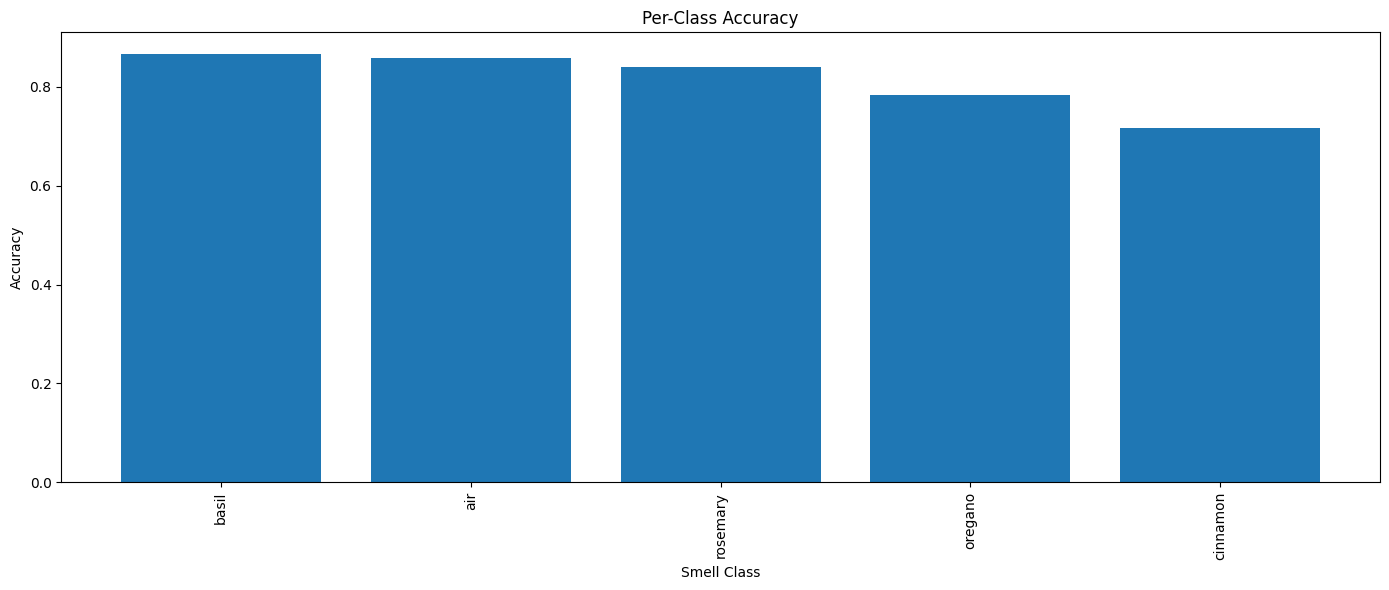

In [106]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()

## Convert to LiteRT model

In [18]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Removed converter.optimizations = [tf.lite.Optimize.DEFAULT] to disable quantization for debugging

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Apply the suggested fix for LSTM models
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
#converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)


INFO:tensorflow:Assets written to: C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa\assets


INFO:tensorflow:Assets written to: C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa\assets


Saved artifact at 'C:\Users\Benedek\AppData\Local\Temp\tmpxmt0x2oa'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2676285444688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285446608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285447568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2676285447184: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 15296 bytes


In [20]:
from ai_edge_litert.compiled_model import CompiledModel
import numpy as np # Import numpy as it's used in the loop

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)

n_correct = 0

for i in range(len(X_test_seq)):
    input_data = np.float32(X_test_seq[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test_seq[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(X_test_seq))


LiteRT accuracy: 0.9065972222222223
